# Introduction to Integrals

A guided notebook on the basic ideas of integration:

- antiderivatives
- indefinite integrals
- definite integrals
- area under a curve
- Riemann sums
- the Fundamental Theorem of Calculus
- linearity of integration

This notebook follows the same style template as the uploaded guidelines.


## 1. Introduction

From basic arithmetic, we know that many operations have inverse operations:

- subtraction is the inverse of addition
- division is the inverse of multiplication

In calculus, **integration** plays the role of the inverse operation to **differentiation**.

Integration is also deeply connected with:
- area under a curve
- accumulation over time
- total change
- physics, engineering, economics, and control systems

In this notebook, we build intuition first, then move to the formal definitions and examples.


## 2. Antiderivatives

Recall that if a function $F(x)$ is differentiable, then its derivative is

$$
F'(x)=\lim_{\Delta x\to 0}\frac{F(x+\Delta x)-F(x)}{\Delta x}
$$

Now suppose we define

$$
f(x)=F'(x)
$$

Then $F$ is called an **antiderivative** of $f$.

So an antiderivative is simply a function whose derivative gives the original function.


## 3. Indefinite Integral

The antiderivative of a function is written using the **indefinite integral**:

$$
\int f(x)\,dx = F(x)+C
$$

where:

- $\int$ is the integral symbol
- $dx$ means we integrate with respect to $x$
- $C$ is the **constant of integration**

The constant appears because the derivative of any constant is zero.


## 4. Why Do We Need the Constant $C$?

Consider:

$$
f(x)=2x
$$

One antiderivative is:

$$
F(x)=x^2
$$

because

$$
\frac{d}{dx}(x^2)=2x
$$

But also:

$$
\frac{d}{dx}(x^2+3)=2x
$$

and

$$
\frac{d}{dx}(x^2-1)=2x
$$

In general:

$$
\frac{d}{dx}(x^2+C)=2x
$$

So:

$$
\int 2x\,dx = x^2 + C
$$

This shows that an indefinite integral represents a **family of curves**.


## 5. Power Rule for Antiderivatives

For powers of $x$:

$$
\int x^n\,dx = \frac{x^{n+1}}{n+1}+C
\qquad n\neq -1
$$

This rule is the reverse of the power rule for derivatives.

Example:

$$
\int x^3\,dx = \frac{x^4}{4}+C
$$

We will later learn more advanced methods such as:
- substitution
- integration by parts
- trigonometric substitution


## 6. Definite Integral and Area

A **definite integral** is an integral over a specific interval:

$$
\int_a^b f(x)\,dx
$$

Its value is a **number**, not a function.

Geometrically, it represents the **signed area** between the graph of $f(x)$ and the $x$-axis on the interval $[a,b]$.


### Example: Constant Function

Let

$$
g(x)=2
$$

on the interval $[0,3]$.

The area under the graph is a rectangle:

$$
A=(3-0)\cdot 2 = 6
$$


### Example: Linear Function

Let

$$
g(x)=x
$$

on the interval $[0,6]$.

The graph forms a right triangle with base $6$ and height $6$, so

$$
A=\frac{1}{2}\cdot 6\cdot 6 = 18
$$


## 7. Approximating Area with Rectangles

For a general function, we may not have a simple geometric formula.

So we divide the interval into many small pieces of width $\Delta x$ and approximate the area using rectangles.

If we choose sample points $x_1,x_2,\dots,x_n$, then the approximate total area is:

$$
A \approx \sum_{i=1}^n f(x_i)\,\Delta x
$$

This is called a **Riemann sum**.


## 8. From Approximation to Exact Area

As the rectangles become thinner:

$$
\Delta x \to 0
$$

the number of rectangles increases:

$$
n\to\infty
$$

and the approximation becomes exact.

This gives the definite integral:

$$
\int_a^b f(x)\,dx
=
\lim_{n\to\infty}\sum_{i=1}^n f(x_i)\,\Delta x
$$

So a definite integral can be understood as the limit of a Riemann sum.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## 9. Visual Example of a Riemann Sum

Let us approximate the area under

$$
f(x)=x^2+1
$$

on the interval $[0,2]$ using rectangles.


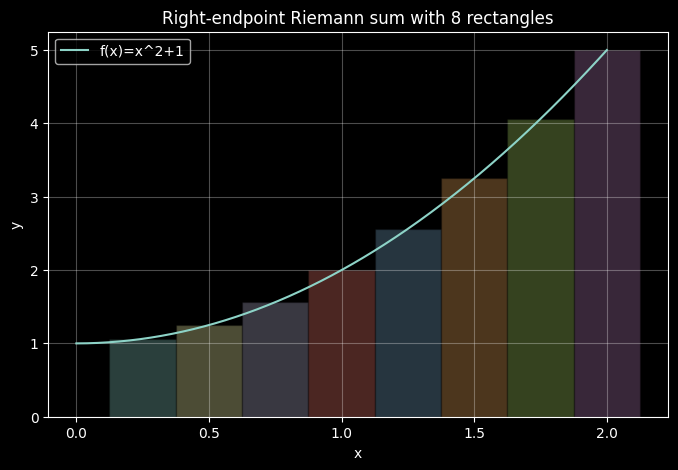

Approximate area: 5.1875


In [5]:
def f(x):
    return x**2 + 1

a, b = 0, 2
n = 8
x = np.linspace(a, b, 400)
y = f(x)

dx = (b - a) / n
x_right = np.linspace(a + dx, b, n)
y_right = f(x_right)

plt.figure(figsize=(8,5))
plt.plot(x, y, label='f(x)=x^2+1')

for xr, yr in zip(x_right, y_right):
    plt.bar(xr - dx/2, yr, width=dx, align='edge', alpha=0.3, edgecolor='black')

plt.title("Right-endpoint Riemann sum with 8 rectangles")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

approx_area = np.sum(y_right * dx)
print("Approximate area:", approx_area)

If we increase the number of rectangles, the approximation improves.


In [6]:
for n in [8, 20, 100]:
    dx = (b - a) / n
    x_right = np.linspace(a + dx, b, n)
    approx_area = np.sum(f(x_right) * dx)
    print(f"n={n:3d}, approximate area = {approx_area:.6f}")

n=  8, approximate area = 5.187500
n= 20, approximate area = 4.870000
n=100, approximate area = 4.706800


## 10. Signed Area

The definite integral gives **signed area**.

If the graph is above the $x$-axis, the area contributes positively.

If the graph is below the $x$-axis, the area contributes negatively.

Example:

$$
f(x)=-3
$$

on $[0,2]$ gives

$$
\int_0^2 -3\,dx = -6
$$

So the integral is negative because the function lies below the axis.


## 11. Useful Conventions for Definite Integrals

Some important rules are:

$$
\int_a^a f(x)\,dx = 0
$$

$$
\int_a^c f(x)\,dx = \int_a^b f(x)\,dx + \int_b^c f(x)\,dx
\qquad (a<b<c)
$$

$$
\int_b^a f(x)\,dx = -\int_a^b f(x)\,dx
$$

These reflect:
- zero width gives zero area
- adjacent intervals add
- reversing bounds changes the sign


## 12. Fundamental Theorem of Calculus

This theorem is one of the most important results in mathematics.

### Part 1

If

$$
F(x)=\int_a^x f(t)\,dt
$$

then

$$
F'(x)=f(x)
$$

This says that differentiation and integration undo each other.


### Part 2

If $F'(x)=f(x)$, then

$$
\int_a^b f(x)\,dx = F(b)-F(a)
$$

This gives a practical way to compute definite integrals:

1. find an antiderivative $F(x)$
2. evaluate it at the upper bound
3. subtract its value at the lower bound


## 13. Worked Example

Compute:

$$
\int_1^3 2x\,dx
$$

First find an antiderivative:

$$
\int 2x\,dx = x^2 + C
$$

So we can take

$$
F(x)=x^2
$$

Now apply the Fundamental Theorem of Calculus:

$$
\int_1^3 2x\,dx = F(3)-F(1)
$$

$$
=3^2-1^2
$$

$$
=9-1=8
$$

So:

$$
\int_1^3 2x\,dx = 8
$$


In [ ]:
x = sp.symbols('x')
result = sp.integrate(2*x, (x, 1, 3))
result

## 14. Accumulation Interpretation

Definite integrals do not only measure geometric area.

They also describe **accumulation**.

For example, if $f(t)$ represents a rate, then

$$
\int_a^x f(t)\,dt
$$

represents the total accumulated quantity from time $a$ to time $x$.

This interpretation is important in:
- physics
- engineering
- economics
- control systems
- probability


## 15. Linearity of Integration

Integration is a linear operation.

### Indefinite integrals

$$
\int k f(x)\,dx = k\int f(x)\,dx
$$

$$
\int (f(x)+g(x))\,dx = \int f(x)\,dx + \int g(x)\,dx
$$

where $k$ is a constant.


### Definite integrals

The same linearity also holds:

$$
\int_a^b k f(x)\,dx = k\int_a^b f(x)\,dx
$$

$$
\int_a^b (f(x)+g(x))\,dx = \int_a^b f(x)\,dx + \int_a^b g(x)\,dx
$$


## 16. Exercises

### Basic

1. Find an antiderivative of $f(x)=3x^2$.

2. Compute:

$$
\int_0^2 4\,dx
$$

3. Compute:

$$
\int_1^3 x\,dx
$$

### Intermediate

4. Compute:

$$
\int_0^1 (x^2+1)\,dx
$$

5. Explain why an indefinite integral includes $+C$.

### Advanced

6. Explain the difference between an indefinite integral and a definite integral.

7. Describe in words what a Riemann sum represents.


## 17. Solutions / Checks

1.

$$
\int 3x^2\,dx = x^3 + C
$$

2.

$$
\int_0^2 4\,dx = 8
$$

3.

$$
\int_1^3 x\,dx = \left[\frac{x^2}{2}\right]_1^3 = \frac{9}{2}-\frac{1}{2}=4
$$

4.

$$
\int_0^1 (x^2+1)\,dx
=
\left[\frac{x^3}{3}+x\right]_0^1
=
\frac{1}{3}+1
=
\frac{4}{3}
$$

5. Because adding any constant does not change the derivative.

6. An indefinite integral gives a family of antiderivatives; a definite integral gives a number over an interval.

7. A Riemann sum approximates total signed area by adding the areas of many thin rectangles.


## 18. Conclusion

In this notebook, we learned that:

- integration is the inverse operation of differentiation
- antiderivatives are written as indefinite integrals
- indefinite integrals include a constant of integration
- definite integrals represent signed area over an interval
- Riemann sums approximate definite integrals
- the Fundamental Theorem of Calculus connects antiderivatives and definite integrals
- integration is linear

These ideas form the foundation for everything that comes next in integral calculus.
